# ՏԱՆ ԳՆԵՐԻ ԿԱՆԽԱՏԵՍՈՒՄ

1. Գրադարանների ներմուծում և միջավայրի կարգավորում

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

def fix_all_seeds(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_all_seeds(22)
print("Environment and seeds are ready.")

Environment and seeds are ready.


2. Տվյալների բեռնում

In [13]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab_Data/Housing.csv')

print("Initial Data Sample (df.head()):")
display(df.head())

print("\nMissing values check (df.isnull().sum()):")
print(df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initial Data Sample (df.head()):


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Missing values check (df.isnull().sum()):
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


3. Տվյալների նախամշակում

In [14]:
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("Data after Preprocessing (df.head()):")
display(df.head())

Data after Preprocessing (df.head()):


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


4․ Տվյալների մասշտաբավորում

In [15]:
X = df.drop('price', axis=1)
y = df['price']

scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

5․ Բաժանում Train և Test խմբերի

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"\nNumber of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")


Number of training samples: 436
Number of testing samples: 109


6․ Թենզորների ստեղծում

In [17]:
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

7․ Մոդելի ճարտարապետությունը

In [18]:
class HousingModel(nn.Module):
    def __init__(self, input_size):
        super(HousingModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.layer1(x), negative_slope=0.01)
        x = torch.nn.functional.leaky_relu(self.layer2(x), negative_slope=0.01)
        return self.output(x)

input_dim = X_train.shape[1]
model = HousingModel(input_dim)
print("Model Architecture:")
print(model)

Model Architecture:
HousingModel(
  (layer1): Linear(in_features=13, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


8. Մոդելի ուսուցում

In [19]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
epochs = 6000
train_losses = []

print("Starting training...")
for i in range(epochs):
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    train_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1) % 600 == 0:
        print(f'Epoch [{i+1}/{epochs}], Loss: {loss.item():.4f}')

Starting training...
Epoch [600/6000], Loss: 0.0119
Epoch [1200/6000], Loss: 0.0096
Epoch [1800/6000], Loss: 0.0088
Epoch [2400/6000], Loss: 0.0084
Epoch [3000/6000], Loss: 0.0081
Epoch [3600/6000], Loss: 0.0078
Epoch [4200/6000], Loss: 0.0076
Epoch [4800/6000], Loss: 0.0075
Epoch [5400/6000], Loss: 0.0073
Epoch [6000/6000], Loss: 0.0072


9. Մոդելի գնահատում և մետրիկաների հաշվարկ

In [20]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss_mse = criterion(predictions, y_test_tensor)

actual_predictions = scaler_y.inverse_transform(predictions.numpy())
actual_prices = scaler_y.inverse_transform(y_test_tensor.numpy())

rmse = np.sqrt(mean_squared_error(actual_prices, actual_predictions))
r2 = r2_score(actual_prices, actual_predictions)

print("\n" + "="*40)
print("       FINAL PERFORMANCE REPORT")
print("="*40)
print(f"Test Loss (MSE): {test_loss_mse.item():.4f}")
print(f"RMSE (Error in currency): {rmse:.2f}")
print(f"R² Score (Accuracy): {r2:.4f}")
print("="*40)

comparison = pd.DataFrame({
    'Actual Price': actual_prices.flatten(),
    'Predicted Price': actual_predictions.flatten()
})
print("\nFirst 10 Predictions Comparison:")
display(comparison.head(10))


       FINAL PERFORMANCE REPORT
Test Loss (MSE): 0.0123
RMSE (Error in currency): 1282614.37
R² Score (Accuracy): 0.6745

First 10 Predictions Comparison:


,Actual Price,Predicted Price
0,4060000.0,4347563.0
1,6650000.0,7049828.5
2,3710000.0,3378921.5
3,6440000.0,4644472.0
4,2800000.0,3437899.0
5,4900000.0,3277653.0
6,5250000.0,5494012.5
7,4543000.0,5992660.0
8,2450000.0,2887760.0
9,3353000.0,3014148.5


10. Արդյունքների վիզուալիզացիա

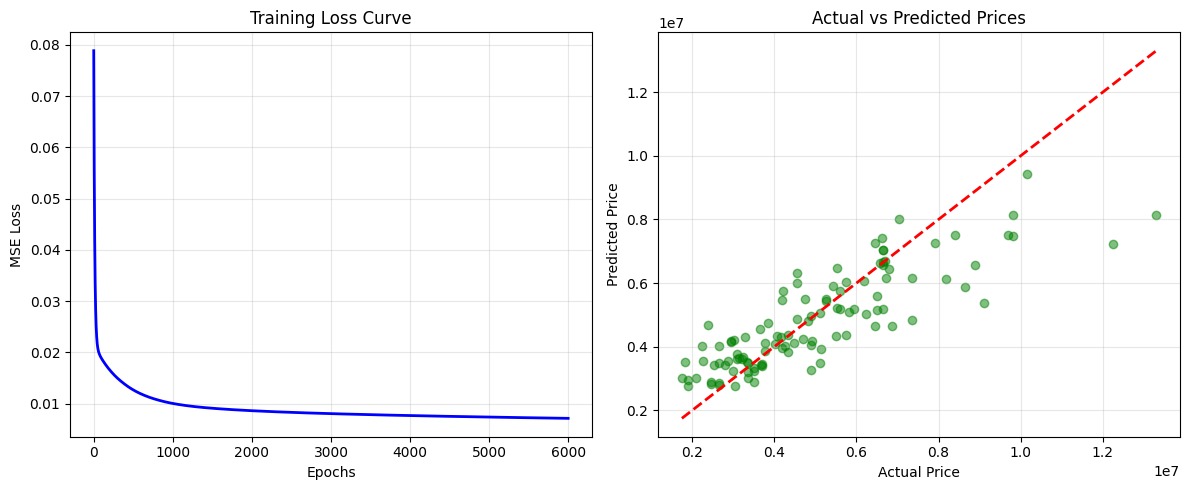

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, color='blue', lw=2)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(actual_prices, actual_predictions, alpha=0.5, color='green')
plt.plot([actual_prices.min(), actual_prices.max()], [actual_prices.min(), actual_prices.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

11․ Մոդելի պահպանում

In [22]:
torch.save(model.state_dict(), 'best_model.pth')
print("Model saved as best_model.pth")

Model saved as best_model.pth
